In [1]:
from typing import TypedDict, List, Annotated
import operator
from langchain_core.agents import AgentAction
from langchain_core.messages import BaseMessage

In [26]:
class AgentState(TypedDict):
    repo: str
    #chat_history: list[BaseMessage]
    #intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]
    #count: int  # Tracks number of processed files
    files: List[str]
    filenames: List[str]
    processed_filenames: Annotated[List[str],  operator.add]
    summaries: Annotated[List[str],  operator.add]
    current_filename: str
    current_file: str


In [3]:
pip install gitingest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 19.1 MB/s eta 0:00:00


In [4]:
import re
from gitingest import ingest

In [65]:
import asyncio
import nest_asyncio

# Apply nest_asyncio to allow nested event loops
nest_asyncio.apply()

def repo_file_details(state: AgentState):

    repo = state["repo"]

    # Use nest_asyncio to run the asynchronous function
    #summary, tree, content = ingest(repo)
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)

    try:
        summary, tree, content = loop.run_until_complete(ingest.ingest_async(repo))
    finally:
        loop.close()

    # Use re.search to find the match
    repo_name = repo.split("/")[-1]

    owner_name = repo.split("/")[-2]

    # Define the delimiter pattern (escape special characters)
    file_pattern = r"\n=+\nFile: .+\n=+\n"

    # Split the content based on the delimiter
    files = re.split(file_pattern, content)

    #print(files[0])

    # Define the regex pattern to match the filename
    filename_pattern = r"File: ([^\n]+)"

    # Find all filenames that match the pattern
    filenames = re.findall(filename_pattern, content)

    #print(filenames[0])
    state["files"] = files
    state["filenames"] = filenames

    #return {"files": files, "filenames": filenames}
    #return "continue"

In [67]:
def decide_file(state: AgentState): #-> Literal["continue", "end"]:
    """Conditional routing function that checks remaining files"""
    remaining_file = None
    for file in state["filenames"]:
        if file not in state["processed_filenames"]:
            remaining_file = file
            break

    state["current_filename"] = remaining_file
    return "continue" if remaining_file else "end"

In [61]:
def file_content(state: AgentState):
    file_name = state["current_filename"]
    file_index = state["filenames"].index(file_name)
    file_content = state["files"][file_index]
    state["current_file"] = file_content

    #return {"current_file": file_content}
    #return "continue"

In [8]:
pip install langchain-deepseek

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.4 MB/s eta 0:00:00


In [9]:
from langchain_deepseek.chat_models import ChatDeepSeek

In [10]:
from google.colab import userdata
deepseek_api_key = ''

In [11]:
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0.7,
    max_tokens=8000,
    api_key=''
)

In [62]:
def generate_summary(state: AgentState):
    summary = llm.invoke({
        "context": {state["current_filename"],
                    state["current_file"]},
        "prompt": "Analyze this code file's purpose, key components, and dependencies:"
    })
    state["summaries"] = [summary]

    #return {"summaries": [summary]}
    #return "continue"

In [63]:
def generate_project_overview(state: AgentState):
    combined = "\n\n".join([
        f"File: {file}\nSummary: {summary}"
        for file, summary in zip(state["processed_files"], state["summaries"])
    ])

    return llm.invoke({
        "context": combined,
        "prompt": "Create comprehensive project documentation covering:\n"
                  "- Architecture overview\n- Component relationships\n- Key system flows"
    })

In [14]:
pip install langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 16.9 MB/s eta 0:00:00


In [15]:
from langchain_core.agents import AgentAction
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

In [16]:
system_prompt = """You are Mini Manus, the great document maker.
Given the user's GitHub repository you must generate a GitHub README.md file for it.

You should aim to generate a professional README.md file that can be committed to the GitHub repository before
providing it to the user. It should have a proper structure similar to the README.md files that are present for the most used GitHub repositories."""

In [17]:
from langgraph.graph import StateGraph, START, END

In [18]:
from IPython.display import Image

In [25]:
#pip install pygraphviz

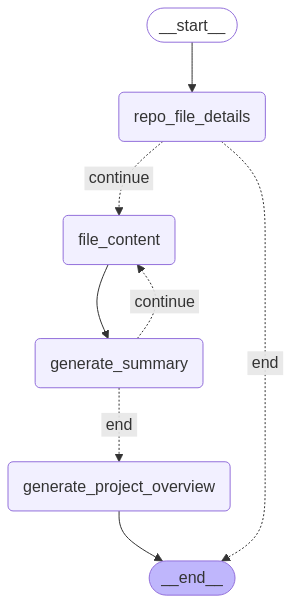

In [34]:
# Initialize graph with FileState
builder = StateGraph(AgentState)

#builder.add_node(START, "repo_file_details")
builder.add_node("repo_file_details", repo_file_details)
#builder.add_node("decide_file", decide_file)
builder.add_node("file_content", file_content)
builder.add_node("generate_summary", generate_summary)
builder.add_node("generate_project_overview", generate_project_overview)

builder.set_entry_point("repo_file_details")

#builder.add_edge("repo_file_details", "decide_file")

builder.add_conditional_edges(
    "repo_file_details",
    decide_file,
    {"continue": "file_content", "end": END}
)

builder.add_edge("file_content", "generate_summary")


# Add conditional edges for file iteration
builder.add_conditional_edges(
    "generate_summary",
    decide_file,
    {"continue": "file_content", "end": "generate_project_overview"}
)

# Final summary edge
builder.add_edge("generate_project_overview", END)



runnable = builder.compile()

Image(runnable.get_graph().draw_mermaid_png())

In [35]:
initial_state = {
    "repo": "https://github.com/pratikkanade/ML_project_h1b_visa_approval_predictions",
    "files": [],
    "filenames": [],
    "processed_filenames": [],
    "summaries": [],
    "current_filename": None,
    "current_file": None
}

In [68]:
result_state = runnable.invoke(initial_state)

https://github.com/pratikkanade/ML_project_h1b_visa_approval_predictions


TypeError: unhashable type: 'dict'

In [21]:
#repo = "https://github.com/pratikkanade/ML_project_h1b_visa_approval_predictions"

#runnable.invoke({"repo":[repo]})
# Run the workflow with dynamic input
#result_state = runnable.invoke(initial_state, {"repo_file_details": {"repo": repo}})
#result_state = runnable.invoke({
#    "repo": "https://github.com/pratikkanade/ML_project_h1b_visa_approval_predictions",
#    "files": [],
#    "filenames": [],
#    "processed_filenames": [],
#    "summaries": [],
#    "current_filename": None,
#    "current_file": None
#})
#config={"repo_file_details": {"repo": repo}})